# Homework 1.1

In [24]:
# using deepseek API

# Create the API key here:
# https://platform.deepseek.com/api_keys

# Install the required library
!pip install -q -U openai

# install dotenv
!pip install -q python-dotenv

In [1]:
from dotenv import load_dotenv
import os
from openai import OpenAI
import time
import json
from pathlib import Path
import uuid

load_dotenv()
api_key = os.getenv("DEEPSEEK_API_KEY")
client = OpenAI(
    api_key=api_key,
    base_url="https://api.deepseek.com"
)

print("Deepseek API initialized successfully")

Deepseek API initialized successfully


In [2]:
# read all files in the articles directory
articles = {}
for path in Path("articles").glob("*.txt"):
    articles[path.name] = path.read_text()
        
print(f"Read {len(articles)} articles.")

Read 10 articles.


In [3]:

# Tell the model to be a helpful assistant that summarizes articles. 
# Provide how you want the summary to be formatted.
instructions = """
You are a helpful assistant that summarizes articles.
Summarize the articles to a person who has not read them nor knows anything about them or the topic.
Output constraints:
- Output 5 bullet points.
- Each bullet point should be no more than 1-2 sentences long.
- Keep the sentences simple and easy to understand, avoiding technical jargon.
- One sentence should be no more than 20 words.
- Neutral tone, no opinions or assumptions.
- Output just the bullet points, no other text.
"""

def ask(text):
    """
    Sends article text to the DeepSeek API and returns a summarized response.
    """
    response = client.chat.completions.create(
        model="deepseek-chat",
        messages=[
            {"role": "system", "content": instructions},
            {"role": "user", "content": text}
        ],
        temperature=0.2,
    )
    return response.choices[0].message.content

summaries = {}
for filename, content in articles.items():
    print(f"Summarizing {filename}...")
    retries = 3
    TIMEOUT = 10
    while retries > 0:
        try:
            summaries[filename] = ask(content)
            print(f"Summarized {filename}.\n")
            break 
        except Exception as e:
            retries -= 1
            if retries > 0:
                print(
                    f"Error, retrying in {TIMEOUT} seconds... "
                    f"({retries} attempts left)"
                )
                time.sleep(TIMEOUT)
            else:
                print(f"Failed after retries: {filename}")
    
    

Summarizing wordpress.txt...
Summarized wordpress.txt.

Summarizing OSM.txt...
Summarized OSM.txt.

Summarizing wayback_machine.txt...
Summarized wayback_machine.txt.

Summarizing wikipedia.txt...
Summarized wikipedia.txt.

Summarizing chatoyancy.txt...
Summarized chatoyancy.txt.

Summarizing youtube.txt...
Summarized youtube.txt.

Summarizing 8086.txt...
Summarized 8086.txt.

Summarizing c_lang.txt...
Summarized c_lang.txt.

Summarizing annas_arch.txt...
Summarized annas_arch.txt.

Summarizing chatgpt.txt...
Summarized chatgpt.txt.



In [4]:
# print all summaries
for filename, summary in summaries.items():
    print(f"Summary of {filename}:\n{summary}\n")
    
# save summaries as json file
with open("summaries.json", "w") as f:
    json.dump(summaries, f, indent=4)

Summary of wordpress.txt:
- WordPress is a free system for building websites and blogs.
- It started in 2003 and is very popular for creating websites.
- Users can change a site's design using different themes.
- Extra features can be added through small programs called plugins.
- It requires a web server to run and is built with PHP.

Summary of OSM.txt:
- OpenStreetMap is a free map database created and updated by volunteers worldwide.
- It was started in 2004 because existing map data was not freely available to the public.
- The project is supported by a non-profit foundation and funded mainly by donations.
- Many companies and websites use its data, especially after other mapping services introduced fees.
- The map data is structured using simple points, lines, and relationships to represent real-world features.

Summary of wayback_machine.txt:
- It is a free online archive that saves old versions of websites.
- People can use it to see how a webpage looked on a specific past date

# Homework 1.2.2

In [5]:
# In this one we will generate 1000 random numbers uniformly distributed between 0 and 1

NEEDED = 1000
BATCH_LIMIT = 100
TIMEOUT = 10
MAX_RETRIES = 3

def build_prompt(count: int, random_seed: str) -> str:
    """Build the prompt for random number generation."""
    return (
        f"Generate {count} random numbers uniformly distributed between 0 and 1.\n"
        f"Output as JSON: {{\"numbers\": [0.123, ...]}}\n"
        f"No markdown, no extra text. 3 decimal places of precision.\n"
        f"{random_seed}"
    )

def generate(count, random_seed):
    """
    Requests 'count' random numbers from the DeepSeek API.
    Returns the raw JSON string response from the model.
    """
    response = client.chat.completions.create(
        model="deepseek-chat",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that generates random numbers."},
            {"role": "user", "content": build_prompt(count, random_seed)}
        ],
        temperature=2,
    )
    return response.choices[0].message.content

all_numbers = []
num_count = 0
iteration = 0
retries = 0
while num_count < NEEDED:
    print(f"Generating numbers... ({num_count}/{NEEDED})")
    try:
        count = min(BATCH_LIMIT, NEEDED - num_count)
        # random_seed = f"Random noise seed: {uuid.uuid4()}"
        random_seed = ""
        print(f"-   Requesting {count} numbers")
        print(f"-   Using random seed: {random_seed}")
        
        output = generate(count, random_seed)
        print(f"Output received: \n{output}")
        
        data = json.loads(output)
        numbers = data.get("numbers", [])
        all_numbers.append(numbers)
        num_count += len(numbers)
        print(f"Generated {len(numbers)} numbers.")
        
        retries = 0 
    except Exception as e:
        retries += 1
        if retries > MAX_RETRIES:
            print(f"Timeout generating numbers: {e}")
            break
        
        print(f"Error generating numbers: {e}")
        print(f"Retrying in {TIMEOUT} seconds...")
        time.sleep(TIMEOUT)

    print("-" * 40)

Generating numbers... (0/1000)
-   Requesting 100 numbers
-   Using random seed: 
Output received: 
{
  "numbers": [
    0.455, 0.831, 0.275, 0.062, 0.730, 0.964, 0.373, 0.195, 0.516, 0.240,
    0.796, 0.017, 0.439, 0.568, 0.121, 0.883, 0.692, 0.412, 0.977, 0.087,
    0.321, 0.604, 0.224, 0.333, 0.746, 0.949, 0.202, 0.549, 0.699, 0.803,
    0.131, 0.669, 0.377, 0.050, 0.847, 0.918, 0.101, 0.280, 0.610, 0.442,
    0.746, 0.027, 0.495, 0.789, 0.359, 0.599, 0.296, 0.041, 0.739, 0.208,
    0.671, 0.157, 0.002, 0.595, 0.890, 0.339, 0.152, 0.912, 0.617, 0.045,
    0.828, 0.323, 0.132, 0.888, 0.386, 0.249, 0.544, 0.982, 0.704, 0.230,
    0.999, 0.403, 0.951, 0.170, 0.686, 0.601, 0.510, 0.133, 0.267, 0.985,
    0.099, 0.329, 0.773, 0.631, 0.138, 0.214, 0.827, 0.432, 0.091, 0.723,
    0.580, 0.871, 0.362, 0.572, 0.808, 0.150, 0.961, 0.419, 0.724, 0.195
  ]
}
Generated 100 numbers.
----------------------------------------
Generating numbers... (100/1000)
-   Requesting 100 numbers
-   Using rand

In [11]:
extra_nums = num_count - len(all_numbers[-1])
if extra_nums > 0:
    all_numbers[-1] = all_numbers[-1][:-extra_nums]

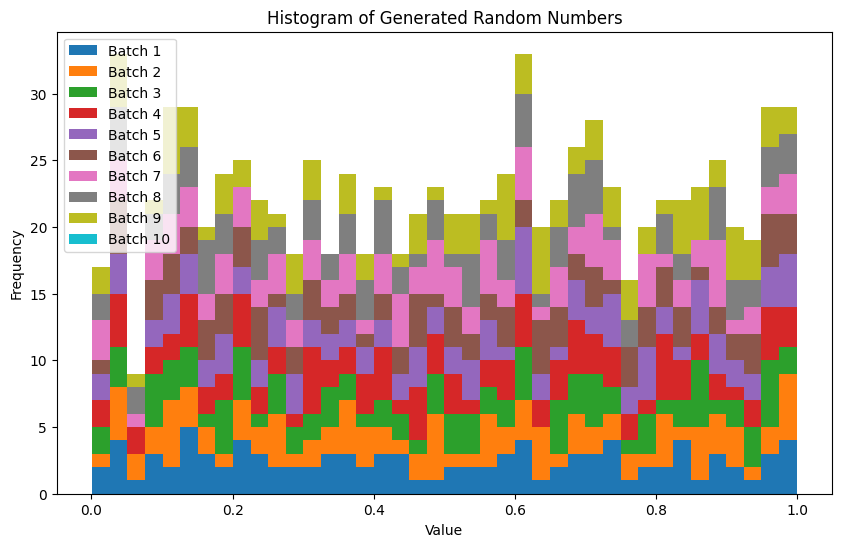

In [12]:
# Now plot them using matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(all_numbers, bins=40, stacked=True, label=[f'Batch {i+1}' for i in range(len(all_numbers))])
plt.title('Histogram of Generated Random Numbers')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()